# Visual State Pretraining — self-supervised pretraining on unlabeled site photos

Этап 1 из предложенного пайплайна для визуального модуля определения фазы (альтернатива/дополнение к equipment-based Module 3).

Что делает этот ноутбук:
- берёт большой **неразмеченный** набор фото со стройплощадок (`IMAGES_DIR`, рекурсивно, без структуры train/val по классам — меток нет и не нужно);
- дообучает визуальный энкодер в режиме self-supervised (без единой метки), чтобы он научился различать визуальные состояния именно ваших площадок;
- сохраняет чекпоинты и, в конце, эмбеддинги всего датасета — это вход для следующих этапов (zero-shot псевдоразметка, кластеризация + active learning, финальная голова классификатора).

**Метод и почему именно он.** Вместо обучения DINO/MAE с нуля (сложная инфраструктура: EMA-teacher + multi-crop + centering, или маскирование + декодер) берём готовый бэкбон, уже предобученный self-supervised на большом внешнем датасете (**DINOv2**, ViT-S/14, веса из `timm`), и **продолжаем self-supervised дообучение на своих фото методом SimSiam**:
- не требует негативных пар и больших батчей (в отличие от SimCLR);
- не требует momentum-encoder и очереди негативов (в отличие от MoCo);
- не требует EMA-teacher, multi-crop и центрирования (в отличие от полного DINO);
- при этом не коллапсирует в тривиальное решение благодаря `stop-gradient` на одной из ветвей — это единственная асимметрия метода.

Тем самым «самообучение» здесь — это не изобретение SSL с нуля, а **доменная адаптация** уже сильного общего SSL-бэкбона под визуальную специфику именно ваших стройплощадок (ракурсы камер, освещение, локальные типовые состояния объектов).

In [1]:
import os
from pathlib import Path

DATA_DIR = Path("data")

# Папка с неразмеченными фото стройплощадок. Поддерживается произвольная
# вложенная структура (по проектам/камерам/датам) — сканируется рекурсивно.
IMAGES_DIR = DATA_DIR / "Строительная техника"

CHECKPOINT_DIR = DATA_DIR / "visual_pretraining_checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

EMBEDDINGS_DIR = DATA_DIR / "visual_pretraining_embeddings"
EMBEDDINGS_DIR.mkdir(parents=True, exist_ok=True)

print("Images:", IMAGES_DIR)
print("Checkpoints:", CHECKPOINT_DIR)
print("Embeddings:", EMBEDDINGS_DIR)


Images: data/Строительная техника
Checkpoints: data/visual_pretraining_checkpoints
Embeddings: data/visual_pretraining_embeddings


In [2]:
# 1. Local paths (альтернатива, если не Colab)

from pathlib import Path

PROJECT_DIR = Path.cwd()

DATA_DIR = PROJECT_DIR / "data"
IMAGES_DIR = DATA_DIR / "Строительная техника"

CHECKPOINT_DIR = PROJECT_DIR / "visual_pretraining_checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

EMBEDDINGS_DIR = PROJECT_DIR / "visual_pretraining_embeddings"
EMBEDDINGS_DIR.mkdir(parents=True, exist_ok=True)

print("Project dir:", PROJECT_DIR)
print("Images:", IMAGES_DIR)
print("Checkpoints:", CHECKPOINT_DIR)
print("Embeddings:", EMBEDDINGS_DIR)

if not IMAGES_DIR.exists():
    raise FileNotFoundError(
        f"Не найдена папка с фото: {IMAGES_DIR}\n"
        "Положите туда (или в подпапки) неразмеченные фото стройплощадок "
        "перед запуском."
    )


Project dir: /home/dan/projects/ConstructionSiteMonitoring/phase_determination
Images: /home/dan/projects/ConstructionSiteMonitoring/phase_determination/data/Строительная техника
Checkpoints: /home/dan/projects/ConstructionSiteMonitoring/phase_determination/visual_pretraining_checkpoints
Embeddings: /home/dan/projects/ConstructionSiteMonitoring/phase_determination/visual_pretraining_embeddings


In [3]:
# 2. Installs, imports, reproducibility, device

try:
    import timm  # noqa: F401
except ImportError:
    %pip install -q timm

import random
import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image, ImageFile
import timm

ImageFile.LOAD_TRUNCATED_IMAGES = True  # не падать на битых/обрезанных jpg из веб-камер

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


/home/dan/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.14.0+cu130
Device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti


## 2b. Доп. данные: HuggingFace `LouisChen15/ConstructionSite` (опционально)

Текущий локальный набор (`data/Строительная техника`) содержит всего 100 фото —
этого недостаточно для осмысленного SimSiam-претрейнинга. Датасет
[**ConstructionSite 10k**](https://huggingface.co/datasets/LouisChen15/ConstructionSite)
даёт ещё 10 013 фото стройплощадок (7009 train + 3004 test, split здесь не важен —
для SSL нужны только сами изображения).

**Лицензия — CC-BY-NC-4.0 (только некоммерческое использование).** Подходит для
некоммерческого/исследовательского использования; при смене статуса проекта на
коммерческий этот источник данных нужно будет пересмотреть.

Сами изображения докачиваются прямо в `IMAGES_DIR` (`list_images()` и так сканирует
рекурсивно, менять код сбора файлов не нужно). Разметка датасета (капшны, VQA по
нарушениям ТБ, bounding box'ы экскаваторов/арматуры/касок) для self-supervised
претрейнинга не используется, но сохраняется отдельным JSONL — она пригодится на
шагах 2 («zero-shot псевдоразметка») и 5 («финальная голова классификатора») из
плана в конце ноутбука.

In [4]:
# 2b. Скачивание доп. датасета LouisChen15/ConstructionSite (HF, CC-BY-NC-4.0, non-commercial)

HF_DATASET_ID = "LouisChen15/ConstructionSite"
HF_IMAGES_SUBDIR = IMAGES_DIR / "hf_construction_site"
HF_ANNOTATIONS_PATH = DATA_DIR / "hf_construction_site_annotations.jsonl"

if HF_IMAGES_SUBDIR.exists() and any(HF_IMAGES_SUBDIR.iterdir()):
    print(f"HF-датасет уже распакован в {HF_IMAGES_SUBDIR}, пропускаю скачивание")
else:
    try:
        from datasets import load_dataset, concatenate_datasets
    except ImportError:
        %pip install -q datasets
        from datasets import load_dataset, concatenate_datasets

    import os
    import json

    # Датасет gated: нужно один раз зайти на страницу датасета под своим HF-аккаунтом
    # и нажать "Agree and access repository" (https://huggingface.co/datasets/LouisChen15/ConstructionSite),
    # затем создать токен на https://huggingface.co/settings/tokens и положить его в
    # переменную окружения HF_TOKEN (или выполнить `huggingface-cli login` в терминале).
    HF_TOKEN = ""
    if not HF_TOKEN:
        raise RuntimeError(
            "Не найден HF_TOKEN. Датасет LouisChen15/ConstructionSite — gated:\n"
            "1) зайдите на https://huggingface.co/datasets/LouisChen15/ConstructionSite "
            "под своим аккаунтом и нажмите 'Agree and access repository';\n"
            "2) создайте токен на https://huggingface.co/settings/tokens;\n"
            "3) установите переменную окружения HF_TOKEN=<токен> (или выполните "
            "`huggingface-cli login` в терминале) и перезапустите эту ячейку."
        )

    HF_IMAGES_SUBDIR.mkdir(parents=True, exist_ok=True)

    # train + test — для self-supervised претрейнинга различие сплитов не важно,
    # нужны только сами изображения.
    ds = load_dataset(HF_DATASET_ID, token=HF_TOKEN)
    full = concatenate_datasets([ds[split] for split in ds.keys()])

    with open(HF_ANNOTATIONS_PATH, "w", encoding="utf-8") as f:
        for i, example in enumerate(full):
            image = example["image"]
            filename = f"{i:06d}.jpg"
            image.convert("RGB").save(HF_IMAGES_SUBDIR / filename, quality=95)

            # Аннотации (капшны/VQA/bbox) для этого ноутбука не нужны, но сохраняем
            # для будущих шагов пайплайна (zero-shot псевдоразметка, голова классификатора).
            meta = {k: v for k, v in example.items() if k != "image"}
            meta["local_filename"] = filename
            f.write(json.dumps(meta, ensure_ascii=False, default=str) + "\n")

    print(f"Скачано и сохранено {len(full)} фото в {HF_IMAGES_SUBDIR}")
    print(f"Аннотации (капшны/VQA/bbox) сохранены в {HF_ANNOTATIONS_PATH}")


HF-датасет уже распакован в /home/dan/projects/ConstructionSiteMonitoring/phase_determination/data/Строительная техника/hf_construction_site, пропускаю скачивание


## 3. Список изображений

Никакой разметки не требуется. Отдельно откладываем небольшую `MONITOR_SUBSET` —
не для валидации точности (её пока нет, меток нет), а для диагностики коллапса
представлений во время обучения (см. ячейку с `embedding_std_diagnostic`).

In [5]:
# 3. Собираем список файлов

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

def list_images(root):
    root = Path(root)
    return sorted(p for p in root.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS)

all_paths = list_images(IMAGES_DIR)
print("Найдено изображений:", len(all_paths))

if len(all_paths) == 0:
    raise RuntimeError(f"В {IMAGES_DIR} не найдено изображений с расширениями {IMAGE_EXTENSIONS}")

rng = random.Random(SEED)
shuffled = all_paths.copy()
rng.shuffle(shuffled)

MONITOR_SIZE = min(512, max(32, len(shuffled) // 20))
monitor_paths = shuffled[:MONITOR_SIZE]
train_paths = shuffled  # обучаем на всём датасете; monitor — это подвыборка ИЗ него, только для диагностики

print(f"Train: {len(train_paths)} | Monitor subset (для диагностики): {len(monitor_paths)}")


Найдено изображений: 10113
Train: 10113 | Monitor subset (для диагностики): 505


## 4. Аугментации и датасет

Каждое изображение превращается в **две независимо аугментированные версии**
(«view1» и «view2») — модель учится делать их представления похожими,
несмотря на разный кроп/цвет/размытие. Это единственный источник сигнала —
меток по-прежнему нет.

Важно для домена стройплощадки: **вертикальный флип не используется** — верх/низ
кадра несёт смысл (низ = грунт/фундамент, верх = каркас/кровля), в отличие от
типичных ImageNet-объектов. Цветовые искажения сделаны умеренными, чтобы не
«стирать» значимые для состояния площадки цветовые признаки (ржавая арматура,
свежий бетон, кирпич).

In [6]:
# 4. Аугментации (два независимых "взгляда" на одно и то же фото) и Dataset

IMAGE_SIZE = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


class TwoViewAugmentation:
    def __init__(self, image_size=IMAGE_SIZE):
        self.transform = transforms.Compose([
            transforms.RandomResizedCrop(
                image_size, scale=(0.4, 1.0),
                interpolation=transforms.InterpolationMode.BICUBIC,
            ),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.3, 0.1)], p=0.8),
            transforms.RandomGrayscale(p=0.1),
            transforms.RandomApply(
                [transforms.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0))], p=0.3
            ),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])

    def __call__(self, image):
        return self.transform(image), self.transform(image)


EVAL_TRANSFORM = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class UnlabeledSiteImages(Dataset):
    """Плоский датасет без меток: возвращает две аугментированные версии одного фото."""

    def __init__(self, paths, augmentation):
        self.paths = paths
        self.augmentation = augmentation

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        try:
            with Image.open(path) as img:
                img = img.convert("RGB")
        except Exception as exc:
            # Битый файл — подменяем соседним, чтобы не падать посреди эпохи.
            print(f"[warn] не удалось открыть {path}: {exc}; беру соседнее изображение")
            return self.__getitem__((idx + 1) % len(self.paths))
        view1, view2 = self.augmentation(img)
        return {"view1": view1, "view2": view2}


class EvalImages(Dataset):
    """Для финального извлечения эмбеддингов: без аугментаций, с путём к файлу."""

    def __init__(self, paths, transform=EVAL_TRANSFORM):
        self.paths = paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        with Image.open(path) as img:
            img = img.convert("RGB")
        return {"image": self.transform(img), "path": str(path)}


## 5. Модель: DINOv2-бэкбон + SimSiam-головы

- **Бэкбон** — `vit_small_patch14_dinov2.lvd142m` из `timm`: ViT-S/14, предобучен
  self-supervised методом DINOv2 на LVD-142M. `dynamic_img_size=True` позволяет
  подавать вход 224×224 вместо родного 518×518 (224 кратно размеру патча 14) — это
  сильно ускоряет обучение на Colab-GPU ценой части детализации; при необходимости
  `IMAGE_SIZE` можно поднять.
- **Projector / Predictor** — стандартные MLP-головы SimSiam (3-слойный проектор
  с BatchNorm, 2-слойный предиктор с узким «бутылочным горлышком»).
- **Асимметрия против коллапса**: `z1, z2` (выход проектора) идут с `.detach()` —
  градиент через них не течёт, только через предсказания `p1, p2`.

In [7]:
# 5. Модель

BACKBONE_NAME = "vit_small_patch14_dinov2.lvd142m"
PROJECTOR_HIDDEN = 2048
PROJECTOR_OUT = 2048
PREDICTOR_HIDDEN = 512


class ProjectionHead(nn.Module):
    def __init__(self, in_dim, hidden_dim=PROJECTOR_HIDDEN, out_dim=PROJECTOR_OUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, hidden_dim, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim, bias=False),
            nn.BatchNorm1d(out_dim, affine=False),
        )

    def forward(self, x):
        return self.net(x)


class PredictionHead(nn.Module):
    def __init__(self, dim=PROJECTOR_OUT, hidden_dim=PREDICTOR_HIDDEN):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, dim),
        )

    def forward(self, x):
        return self.net(x)


class SimSiamModel(nn.Module):
    def __init__(self, backbone_name=BACKBONE_NAME, image_size=IMAGE_SIZE, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            num_classes=0,
            img_size=image_size,
            dynamic_img_size=True,
        )
        embed_dim = self.backbone.num_features
        self.projector = ProjectionHead(embed_dim)
        self.predictor = PredictionHead()

    def forward(self, view1, view2):
        f1 = self.backbone(view1)
        f2 = self.backbone(view2)
        z1, z2 = self.projector(f1), self.projector(f2)
        p1, p2 = self.predictor(z1), self.predictor(z2)
        # stop-gradient: z идёт как "мишень" без градиента — единственная
        # асимметрия SimSiam, которая не даёт представлению схлопнуться в константу.
        return p1, p2, z1.detach(), z2.detach()


model = SimSiamModel(pretrained=True).to(device)
print("Backbone:", BACKBONE_NAME)
print("Embed dim:", model.backbone.num_features)
print("Parameters (total):", sum(p.numel() for p in model.parameters()))
print("Parameters (backbone):", sum(p.numel() for p in model.backbone.parameters()))


Backbone: vit_small_patch14_dinov2.lvd142m
Embed dim: 384
Parameters (total): 32912256
Parameters (backbone): 21628800


## 6. Loss, диагностика коллапса, чекпоинты

SimSiam-лосс — отрицательное косинусное сходство между предсказанием одной
ветви и «мишенью» (detached-проекцией) другой, симметрично для обеих ветвей.

**Диагностика коллапса** — главный практический риск self-supervised обучения
без негативных пар: модель может «сжульничать» и научиться выдавать одинаковый
вектор для любого входа (loss при этом тоже уйдёт к −1, выглядя как «идеальное»
обучение). Отслеживаем это по среднему std нормированных эмбеддингов на
`MONITOR_SUBSET`: у здорового представления это значение стабилизируется около
`1/sqrt(dim)`, у схлопнувшегося — уходит к нулю.

In [8]:
# 6. Loss, диагностика, чекпоинты

def negative_cosine_similarity(p, z):
    p = F.normalize(p, dim=-1)
    z = F.normalize(z, dim=-1)
    return -(p * z).sum(dim=-1).mean()


def simsiam_loss(p1, p2, z1, z2):
    return 0.5 * negative_cosine_similarity(p1, z2) + 0.5 * negative_cosine_similarity(p2, z1)


@torch.no_grad()
def embedding_std_diagnostic(model, paths, batch_size=64):
    """Среднее std L2-нормированных backbone-эмбеддингов. Ожидаемо ~1/sqrt(dim)
    при здоровом обучении; падение к 0 сигнализирует о коллапсе представления."""
    model.eval()
    loader = DataLoader(EvalImages(paths), batch_size=batch_size, shuffle=False, num_workers=2)
    feats = []
    for batch in loader:
        x = batch["image"].to(device, non_blocking=True)
        f = model.backbone(x)
        feats.append(F.normalize(f, dim=-1).cpu())
    feats = torch.cat(feats, dim=0)
    model.train()
    return feats.std(dim=0).mean().item()


def save_checkpoint(model, optimizer, scheduler, epoch, train_loss, embed_std, path):
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict() if scheduler else None,
            "train_loss": train_loss,
            "embed_std": embed_std,
            "config": {
                "backbone_name": BACKBONE_NAME,
                "image_size": IMAGE_SIZE,
                "projector_hidden": PROJECTOR_HIDDEN,
                "projector_out": PROJECTOR_OUT,
                "predictor_hidden": PREDICTOR_HIDDEN,
            },
        },
        path,
    )


In [9]:
# 7. Конфигурация обучения

BATCH_SIZE = 128          # уменьшите, если не хватает памяти GPU (BatchNorm в головах
                           # чувствителен к маленьким батчам — не ставьте ниже ~32)
EPOCHS = 50
BASE_LR = 0.05 * (BATCH_SIZE / 256)   # линейное масштабирование lr от батча, как в оригинале SimSiam

# Бэкбон — уже сильно предобученный DINOv2, а не случайная инициализация (как
# ResNet50 в оригинальной статье SimSiam), поэтому учим его на порядок медленнее
# голов. В первом прогоне одинаковый BASE_LR для всех параметров быстро разрушил
# предобученные признаки: embed_std упал в 3-15 раз ниже эталона 1/sqrt(dim) уже
# к эпохе 2-3 и не восстановился за 26 эпох (см. checkpoint_epoch_002..026.pt).
BACKBONE_LR_MULT = 0.1
FREEZE_BACKBONE_EPOCHS = 2   # первые эпохи учим только головы (backbone заморожен) —
                              # аналог linear-probing перед fine-tuning'ом, чтобы
                              # случайно инициализированные головы не гнали в
                              # предобученный бэкбон хаотичный градиент со старта

WEIGHT_DECAY = 1e-4
MOMENTUM = 0.9
WARMUP_EPOCHS = 5
NUM_WORKERS = 4

train_dataset = UnlabeledSiteImages(train_paths, TwoViewAugmentation(IMAGE_SIZE))
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    drop_last=True,     # BatchNorm в головах требует batch_size > 1 на каждом шаге
    pin_memory=(device.type == "cuda"),
)

# SimSiam по оригинальной статье использует SGD, а не Adam — с Adam риск
# коллапса заметно выше при отсутствии момент-энкодера/очереди негативов.
# Раздельные lr-группы: backbone учится с BASE_LR * BACKBONE_LR_MULT, головы — с BASE_LR.
optimizer = torch.optim.SGD(
    [
        {"params": model.backbone.parameters(), "lr": BASE_LR * BACKBONE_LR_MULT},
        {"params": model.projector.parameters(), "lr": BASE_LR},
        {"params": model.predictor.parameters(), "lr": BASE_LR},
    ],
    lr=BASE_LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
)

for p in model.backbone.parameters():
    p.requires_grad_(FREEZE_BACKBONE_EPOCHS == 0)


def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1 + math.cos(math.pi * progress))


scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

print("Batches per epoch:", len(train_loader))
print("Base LR (heads):", BASE_LR)
print("Base LR (backbone):", BASE_LR * BACKBONE_LR_MULT)
print("Backbone frozen for first", FREEZE_BACKBONE_EPOCHS, "epoch(s)")


Batches per epoch: 79
Base LR (heads): 0.025
Base LR (backbone): 0.0025000000000000005
Backbone frozen for first 2 epoch(s)


In [ ]:
# 8. Обучение
#
# Критерий выбора best.pt прошёл через два неверных варианта, прежде чем
# устоялся — стоит держать оба урока в комментарии:
#  1) "минимальный train_loss" (исходный вариант) — плохо, потому что у SimSiam
#     loss тривиально уходит к -1 при коллапсе в константу. В первом прогоне
#     (общий lr на весь backbone, без заморозки) это выбрало эпоху 6 с одним из
#     самых низких embed_std среди всех 26 эпох (0.0048 против эталона ~0.051):
#     "лучший" по loss чекпоинт оказался худшим по факту.
#  2) "максимальный embed_std" (второй вариант) — тоже плохо, но по другой
#     причине: во втором прогоне (раздельный lr + заморозка backbone) коллапса
#     уже не было ни на одной эпохе, но embed_std ЗАКОНОМЕРНО снижается по ходу
#     доменной адаптации (представление специализируется под более узкий домен
#     стройплощадок, а не под общий ImageNet-масштаб DINOv2) — то есть чистая
#     максимизация embed_std выбрала эпоху 1, ДО начала адаптации (backbone ещё
#     заморожен), когда loss почти нулевой и головы ничему не научились.
# Правильно — комбинация: embed_std используется только как ФИЛЬТР коллапса
# (отсекаем совсем схлопнутые эпохи), а среди прошедших фильтр выбираем по
# минимальному train_loss, как и предполагает обучение SimSiam.
# Если фильтр не пройдёт НИ ОДНА эпоха (полный коллапс всего прогона) — на
# всякий случай сохраняем как best.pt наименее схлопнутую эпоху, чтобы
# последующие ячейки (10-11) не падали на отсутствующем файле, и явно
# предупреждаем об этом в финальном сообщении.
#
# ВАЖНО: следите за embed_std в логе — устойчивое падение к 0 означает коллапс,
# нужно остановиться и понизить lr / увеличить batch size / уменьшить веса проекторов.

REFERENCE_STD = 1 / math.sqrt(model.backbone.num_features)
COLLAPSE_STD_FLOOR = 0.3 * REFERENCE_STD

history = {"train_loss": [], "embed_std": [], "lr": []}
best_train_loss = float("inf")
best_embed_std_fallback = -float("inf")
have_valid_best = False

for epoch in range(1, EPOCHS + 1):
    backbone_trainable = epoch > FREEZE_BACKBONE_EPOCHS
    for p in model.backbone.parameters():
        p.requires_grad_(backbone_trainable)

    model.train()
    running_loss = 0.0
    n_batches = 0

    for batch in train_loader:
        v1 = batch["view1"].to(device, non_blocking=True)
        v2 = batch["view2"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            p1, p2, z1, z2 = model(v1, v2)
            loss = simsiam_loss(p1, p2, z1, z2)

        if scaler.is_enabled():
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 3.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 3.0)
            optimizer.step()

        running_loss += loss.item()
        n_batches += 1

    scheduler.step()
    train_loss = running_loss / max(n_batches, 1)
    embed_std = embedding_std_diagnostic(model, monitor_paths)
    lr = optimizer.param_groups[-1]["lr"]  # lr голов; backbone = lr * BACKBONE_LR_MULT

    history["train_loss"].append(train_loss)
    history["embed_std"].append(embed_std)
    history["lr"].append(lr)

    epoch_path = CHECKPOINT_DIR / f"checkpoint_epoch_{epoch:03d}.pt"
    save_checkpoint(model, optimizer, scheduler, epoch, train_loss, embed_std, epoch_path)

    is_collapsed = embed_std < COLLAPSE_STD_FLOOR
    is_new_best = False
    if not is_collapsed and train_loss < best_train_loss:
        best_train_loss = train_loss
        have_valid_best = True
        is_new_best = True
    elif not have_valid_best and embed_std > best_embed_std_fallback:
        # ни одна эпоха ещё не прошла фильтр коллапса — держим как best.pt
        # наименее схлопнутую эпоху, а не оставляем файл отсутствующим
        best_embed_std_fallback = embed_std
        is_new_best = True

    if is_new_best:
        best_path = CHECKPOINT_DIR / "best.pt"
        save_checkpoint(model, optimizer, scheduler, epoch, train_loss, embed_std, best_path)
        best_marker = "  <-- BEST" if have_valid_best else "  <-- BEST (fallback, коллапс)"
    else:
        best_marker = ""

    collapse_flag = "  [!] возможен коллапс" if is_collapsed else ""
    frozen_flag = "  [backbone frozen]" if not backbone_trainable else ""
    print(
        f"Epoch {epoch:03d}/{EPOCHS} | "
        f"lr={lr:.4f} | "
        f"loss={train_loss:.4f} | "
        f"embed_std={embed_std:.4f} (эталон ~{REFERENCE_STD:.4f})"
        f"{best_marker}{collapse_flag}{frozen_flag}"
    )

print("Training finished.")
if have_valid_best:
    print("Best train loss (non-collapsed):", best_train_loss)
else:
    print(
        "[!] Ни одна эпоха не прошла фильтр коллапса (embed_std < "
        f"{COLLAPSE_STD_FLOOR:.4f} на всём прогоне). best.pt сохранён как "
        "fallback (наименее схлопнутая эпоха) — эмбеддинги из него, скорее "
        "всего, малополезны. Нужно понизить lr / увеличить FREEZE_BACKBONE_EPOCHS "
        "и переобучить."
    )
print("Checkpoints:", CHECKPOINT_DIR)


In [10]:
# 9. Resume после обрыва (Colab-дисконнект и т.п.)
#
# ВАЖНО: работает только для чекпоинтов, сохранённых ЭТОЙ (обновлённой) версией
# ноутбука — optimizer теперь хранит 3 param group (backbone/projector/predictor)
# вместо одной, так что optimizer.load_state_dict упадёт на чекпоинтах из старого
# прогона (backup: visual_pretraining_checkpoints_run1_collapsed/). Те чекпоинты
# в любом случае устарели: они получены с общим lr на весь backbone и
# представление в них схлопнуто (embed_std << 1/sqrt(dim) на всех 26 эпохах).

def resume_from_checkpoint(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    if checkpoint.get("scheduler_state_dict") is not None:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    start_epoch = checkpoint["epoch"] + 1
    best_train_loss = checkpoint.get("train_loss", float("inf"))

    return start_epoch, best_train_loss


# Пример:
# start_epoch, best_train_loss = resume_from_checkpoint(
#     CHECKPOINT_DIR / "checkpoint_epoch_010.pt"
# )
# print("Resume from epoch:", start_epoch)


## 10. Извлечение эмбеддингов всего датасета

Финальный шаг этого ноутбука: прогнать через дообученный бэкбон **весь**
неразмеченный набор (не только `monitor_paths`) и сохранить эмбеддинги на диск.
Это и есть вход для следующих шагов пайплайна:
- **zero-shot псевдоразметка** — сравнение этих эмбеддингов (или текстового
  энкодера той же природы) с текстовыми описаниями фаз;
- **кластеризация + active learning** — поиск визуально однородных групп фото
  и разметка представителей/пограничных случаев вместо всего датасета;
- **финальная голова классификатора** — обучение поверх замороженного бэкбона.

In [11]:
# 10. Извлечение эмбеддингов всего датасета

best_checkpoint = torch.load(CHECKPOINT_DIR / "best.pt", map_location=device)
model.load_state_dict(best_checkpoint["model_state_dict"])
model.eval()
print("Загружен чекпоинт эпохи", best_checkpoint["epoch"], "| train_loss =", best_checkpoint["train_loss"])

eval_loader = DataLoader(
    EvalImages(all_paths),
    batch_size=128,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

all_embeddings = []
all_image_paths = []

with torch.no_grad():
    for batch in eval_loader:
        x = batch["image"].to(device, non_blocking=True)
        feats = model.backbone(x)
        all_embeddings.append(feats.cpu().numpy())
        all_image_paths.extend(batch["path"])

all_embeddings = np.concatenate(all_embeddings, axis=0)
print("Embeddings shape:", all_embeddings.shape)

np.save(EMBEDDINGS_DIR / "embeddings.npy", all_embeddings)
with open(EMBEDDINGS_DIR / "image_paths.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(all_image_paths))

print("Сохранено:", EMBEDDINGS_DIR / "embeddings.npy")
print("Сохранено:", EMBEDDINGS_DIR / "image_paths.txt")


Загружен чекпоинт эпохи 49 | train_loss = -0.9526646529571919


Embeddings shape: (10113, 384)
Сохранено: /home/dan/projects/ConstructionSiteMonitoring/phase_determination/visual_pretraining_embeddings/embeddings.npy
Сохранено: /home/dan/projects/ConstructionSiteMonitoring/phase_determination/visual_pretraining_embeddings/image_paths.txt


## 11. Быстрая проверка на глаз: 2D-проекция эмбеддингов

Без единой метки — просто визуально смотрим, разбивается ли облако точек на
плотные группы (это будет предварительным сигналом, что задача вообще решаема
по внешнему виду, до следующего шага с кластеризацией и активным обучением).

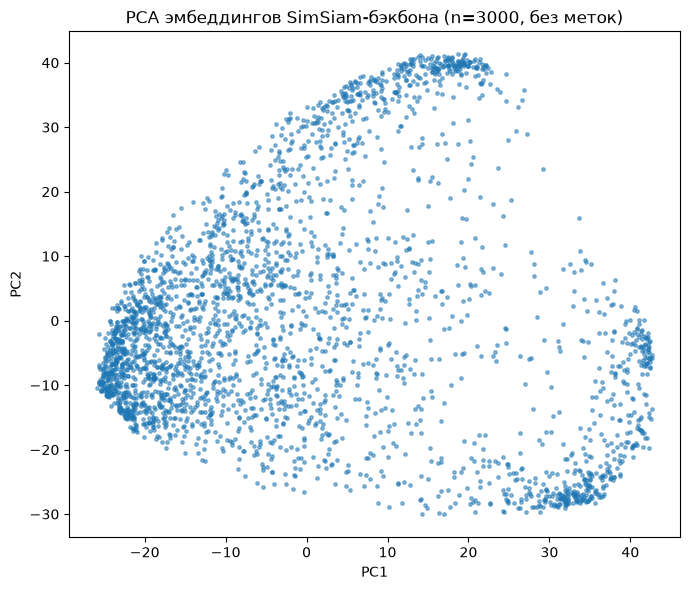

Объяснённая дисперсия (PC1, PC2): [0.41629422 0.35341564]


In [12]:
# 11. PCA-проекция эмбеддингов для визуальной проверки

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

sample_size = min(3000, len(all_embeddings))
sample_idx = rng.sample(range(len(all_embeddings)), sample_size)
sample = all_embeddings[sample_idx]

pca = PCA(n_components=2, random_state=SEED)
proj = pca.fit_transform(sample)

plt.figure(figsize=(7, 6))
plt.scatter(proj[:, 0], proj[:, 1], s=6, alpha=0.5)
plt.title(f"PCA эмбеддингов SimSiam-бэкбона (n={sample_size}, без меток)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig(EMBEDDINGS_DIR / "pca_preview.png", dpi=150)
plt.show()

print("Объяснённая дисперсия (PC1, PC2):", pca.explained_variance_ratio_)


## Дальше

Этот ноутбук закрывает шаг 1 пайплайна («самообучение»). Следующие шаги — по
уже сохранённым `embeddings.npy` / `image_paths.txt`:

2. **Zero-shot псевдоразметка** — прогнать фото (или уже посчитанные эмбеддинги,
   если энкодер текста и картинок общий) через vision-language модель с
   текстовыми промптами-описаниями фаз/под-фаз из листа
   «Итоговая_карта_фаза_техника» сводной таблицы.
3. **Слабая метка по дате плана** — там, где к фото привязан `project_id` + `timestamp`
   и для проекта есть канонический план с датами фаз.
4. **Кластеризация + active learning** — кластеризовать `embeddings.npy`
   (k-means/HDBSCAN) и разметить вручную представителей кластеров и
   пограничные случаи.
5. **Финальная голова классификатора** — дообучить лёгкую голову поверх
   замороженного бэкбона на своде меток из шагов 2–4. Это и есть
   `VisualStateEncoder`, о котором шла речь раньше.